In [10]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV


In [11]:
# 1. Definir las rutas de los archivos CSV preprocesados
path_train = "dfFinalMWB_Train/MWB_TRAIN.csv"
path_test  = "dfFinalMWB_Test/MWB_Test.csv"

# 2. Cargar los datasets
df_train = pd.read_csv(path_train)
df_test  = pd.read_csv(path_test)

# 3. Verificación de carga
print("==============================================")
print("        DATASETS CARGADOS CON ÉXITO           ")
print("==============================================")
print(f"Dimensiones de Train: {df_train.shape[0]} filas, {df_train.shape[1]} columnas")
print(f"Dimensiones de Test:  {df_test.shape[0]} filas, {df_test.shape[1]} columnas")

print("\n--- Tipos de datos en Train ---")
print(df_train.dtypes)

print("\n--- Primeras 5 filas de Train ---")
display(df_train.head())

        DATASETS CARGADOS CON ÉXITO           
Dimensiones de Train: 1157 filas, 30 columnas
Dimensiones de Test:  321 filas, 30 columnas

--- Tipos de datos en Train ---
User_ID                          object
Age                               int64
Gender                           object
Occupation                       object
Relationship_Status              object
Primary_Platform                 object
Daily_Usage_Hours               float64
Platforms_Used_Count              int64
Posts_Per_Week                    int64
Late_Night_Usage                   bool
First_Check_Morning              object
Notifications_Per_Day             int64
FOMO_Score                      float64
Social_Comparison_Score         float64
Validation_Seeking_Score        float64
Scroll_Without_Purpose          float64
Tried_To_Cut_Back                  bool
Failed_To_Cut_Back                 bool
Anxiety_Score                   float64
Depression_Score                float64
Loneliness_Score             

,User_ID,Age,Gender,Occupation,Relationship_Status,Primary_Platform,Daily_Usage_Hours,Platforms_Used_Count,Posts_Per_Week,Late_Night_Usage,...,Loneliness_Score,Self_Esteem_Score,Sleep_Quality_Score,Sleep_Hours,Productivity_Loss_Score,Offline_Relationship_Quality,Physical_Activity_Hrs_Week,Screen_Free_Time_Hrs,Mental_Wellbeing_Score,Addiction_Level
0,USR00001,30,MALE,WORKING PROFESSIONAL,IN A RELATIONSHIP,YOUTUBE,2.9,4,3,False,...,1.7,6.5,8.5,5.3,3.7,3.8,5.8,3.1,7.3,LOW
1,USR00002,19,MALE,STUDENT,MARRIED,INSTAGRAM,4.8,1,0,True,...,7.0,7.5,7.8,5.5,4.0,1.8,0.9,3.3,4.1,SEVERE
2,USR00003,40,MALE,STUDENT,IN A RELATIONSHIP,YOUTUBE,4.4,4,5,False,...,5.6,5.3,6.3,6.6,5.8,2.8,0.0,1.5,5.6,HIGH
3,USR00007,38,FEMALE,STUDENT,IN A RELATIONSHIP,FACEBOOK,5.0,4,4,True,...,7.2,0.5,4.8,8.2,6.8,5.4,3.2,3.7,5.5,HIGH
4,USR00008,22,FEMALE,UNEMPLOYED,SINGLE,TWITTER/X,3.4,5,2,False,...,3.1,2.9,3.8,10.0,6.8,6.7,2.9,6.6,6.2,MODERATE


In [12]:
# 1. Definir la variable objetivo
le = LabelEncoder()
df_train['Addiction_Level'] = le.fit_transform(df_train['Addiction_Level'])
df_test['Addiction_Level'] = le.transform(df_test['Addiction_Level'])
target_col = "Addiction_Level"

columnas_a_dropear = [
    "User_ID",                 
    "Mental_Wellbeing_Score",         
    "Anxiety_Score",           
    "Depression_Score",       
    "Loneliness_Score",        
    "Self_Esteem_Score",       
    "FOMO_Score",              
    "Social_Comparison_Score", 
    "Validation_Seeking_Score",
    "Productivity_Loss_Score",
    "Sleep_Quality_Score"
]

# 3. Separar X (Características) e y (Variable Objetivo) para TRAIN
X_train = df_train.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_train = df_train[target_col]

# 4. Separar X e y para TEST
X_test = df_test.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_test = df_test[target_col]

# 5. Comprobación
print("==============================================")
print("        SEPARACIÓN Y LIMPIEZA COMPLETADA      ")
print("==============================================")
print(f"Dimensiones de X_train (Predictoras): {X_train.shape}")
print(f"Dimensiones de y_train (Objetivo):    {y_train.shape}")
print(f"Dimensiones de X_test (Predictoras):  {X_test.shape}")
print(f"Dimensiones de y_test (Objetivo):     {y_test.shape}")

print("\nColumnas que usará el modelo para aprender:")
print(list(X_train.columns))

        SEPARACIÓN Y LIMPIEZA COMPLETADA      
Dimensiones de X_train (Predictoras): (1157, 18)
Dimensiones de y_train (Objetivo):    (1157,)
Dimensiones de X_test (Predictoras):  (321, 18)
Dimensiones de y_test (Objetivo):     (321,)

Columnas que usará el modelo para aprender:
['Age', 'Gender', 'Occupation', 'Relationship_Status', 'Primary_Platform', 'Daily_Usage_Hours', 'Platforms_Used_Count', 'Posts_Per_Week', 'Late_Night_Usage', 'First_Check_Morning', 'Notifications_Per_Day', 'Scroll_Without_Purpose', 'Tried_To_Cut_Back', 'Failed_To_Cut_Back', 'Sleep_Hours', 'Offline_Relationship_Quality', 'Physical_Activity_Hrs_Week', 'Screen_Free_Time_Hrs']


In [13]:
# 1. Identificar cuáles son las columnas numéricas
columnas_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns

print(f"Se van a escalar las siguientes columnas numéricas:\n{list(columnas_numericas)}\n")

# 2. Inicializar el StandardScaler
scaler = StandardScaler()

# 3. Ajustar  y transformar
X_train[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

# ==========================================
# 5. Comprobación de que se hizo correctamente
# ==========================================
print("--- Comprobación en TRAIN ---")
print("La media de Train debería ser muy cercana a 0:")
print(X_train[columnas_numericas].mean().round(2))
print("\nLa desviación estándar de Train debería ser 1:")
print(X_train[columnas_numericas].std().round(2))

print("\n--- Primeras filas de X_train escalado ---")
display(X_train.head()) 

Se van a escalar las siguientes columnas numéricas:
['Age', 'Daily_Usage_Hours', 'Platforms_Used_Count', 'Posts_Per_Week', 'Notifications_Per_Day', 'Scroll_Without_Purpose', 'Sleep_Hours', 'Offline_Relationship_Quality', 'Physical_Activity_Hrs_Week', 'Screen_Free_Time_Hrs']

--- Comprobación en TRAIN ---
La media de Train debería ser muy cercana a 0:
Age                            -0.0
Daily_Usage_Hours               0.0
Platforms_Used_Count            0.0
Posts_Per_Week                 -0.0
Notifications_Per_Day          -0.0
Scroll_Without_Purpose          0.0
Sleep_Hours                    -0.0
Offline_Relationship_Quality    0.0
Physical_Activity_Hrs_Week      0.0
Screen_Free_Time_Hrs           -0.0
dtype: float64

La desviación estándar de Train debería ser 1:
Age                             1.0
Daily_Usage_Hours               1.0
Platforms_Used_Count            1.0
Posts_Per_Week                  1.0
Notifications_Per_Day           1.0
Scroll_Without_Purpose          1.0
Sleep_Ho

,Age,Gender,Occupation,Relationship_Status,Primary_Platform,Daily_Usage_Hours,Platforms_Used_Count,Posts_Per_Week,Late_Night_Usage,First_Check_Morning,Notifications_Per_Day,Scroll_Without_Purpose,Tried_To_Cut_Back,Failed_To_Cut_Back,Sleep_Hours,Offline_Relationship_Quality,Physical_Activity_Hrs_Week,Screen_Free_Time_Hrs
0,0.067334,MALE,WORKING PROFESSIONAL,IN A RELATIONSHIP,YOUTUBE,-0.789127,0.456438,-0.491000,False,WITHIN 5 MIN,0.058735,2.189671,False,False,-0.899325,-0.832606,1.667503,0.072920
1,-1.221326,MALE,STUDENT,MARRIED,INSTAGRAM,0.132625,-1.343900,-2.132871,True,WITHIN 5 MIN,1.544618,1.711265,True,True,-0.753349,-1.821444,-1.272773,0.196357
2,1.238843,MALE,STUDENT,IN A RELATIONSHIP,YOUTUBE,-0.061428,0.456438,0.603580,False,WITHIN 5 MIN,1.878184,0.323886,False,True,0.049521,-1.327025,-1.812824,-0.914570
3,1.004541,FEMALE,STUDENT,IN A RELATIONSHIP,FACEBOOK,0.229652,0.456438,0.056290,True,WITHIN 5 MIN,-1.093583,-1.350537,False,True,1.217331,-0.041536,0.107357,0.443229
4,-0.869873,FEMALE,UNEMPLOYED,SINGLE,TWITTER/X,-0.546561,1.056551,-1.038291,False,WITHIN 5 MIN,0.119383,-0.680768,True,False,2.531118,0.601208,-0.072660,2.233056


In [14]:
# 1. Definir qué columnas son categóricas
columnas_categoricas = ['Gender', 'Occupation', 'Relationship_Status', 'Primary_Platform','First_Check_Morning']

# 2. Aplicar One-Hot Encoding a Train y Test
X_train_codificado = pd.get_dummies(X_train, columns=columnas_categoricas, drop_first=True)
X_test_codificado = pd.get_dummies(X_test, columns=columnas_categoricas, drop_first=True)

# 3. ALINEAR Train y Test (Crucial)
X_train_codificado, X_test_codificado = X_train_codificado.align(X_test_codificado, join='left', axis=1, fill_value=0)

print(f"Columnas finales para entrenar: {X_train_codificado.shape[1]}")

Columnas finales para entrenar: 31


In [15]:
display(X_train_codificado.head())

,Age,Daily_Usage_Hours,Platforms_Used_Count,Posts_Per_Week,Late_Night_Usage,Notifications_Per_Day,Scroll_Without_Purpose,Tried_To_Cut_Back,Failed_To_Cut_Back,Sleep_Hours,...,Relationship_Status_SINGLE,Relationship_Status_UNKNOWN,Primary_Platform_INSTAGRAM,Primary_Platform_SNAPCHAT,Primary_Platform_TIKTOK,Primary_Platform_TWITTER/X,Primary_Platform_UNKNOWN,Primary_Platform_YOUTUBE,First_Check_Morning_AFTER 30 MIN,First_Check_Morning_WITHIN 5 MIN
0,0.067334,-0.789127,0.456438,-0.491000,False,0.058735,2.189671,False,False,-0.899325,...,False,False,False,False,False,False,False,True,False,True
1,-1.221326,0.132625,-1.343900,-2.132871,True,1.544618,1.711265,True,True,-0.753349,...,False,False,True,False,False,False,False,False,False,True
2,1.238843,-0.061428,0.456438,0.603580,False,1.878184,0.323886,False,True,0.049521,...,False,False,False,False,False,False,False,True,False,True
3,1.004541,0.229652,0.456438,0.056290,True,-1.093583,-1.350537,False,True,1.217331,...,False,False,False,False,False,False,False,False,False,True
4,-0.869873,-0.546561,1.056551,-1.038291,False,0.119383,-0.680768,True,False,2.531118,...,True,False,False,False,False,True,False,False,False,True


In [16]:
# 1. Definir el modelo base
logreg_model = LogisticRegression(
    random_state=46,
    max_iter=5000
)

# 2. Definir la parrilla de hiperparámetros que quieres probar
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
}

# 3. Configurar el GridSearch con Validación Cruzada (5 folds)
grid_search = GridSearchCV(
    estimator=logreg_model,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("--- Iniciando búsqueda de hiperparámetros (Grid Search) ---")

grid_search.fit(X_train_codificado, y_train)

# 4. Ver los mejores resultados
print("\n==============================================")
print("       MEJORES HIPERPARÁMETROS ENCONTRADOS    ")
print("==============================================")
print(grid_search.best_params_)
print(f"Mejor F1 Weighted en Validación Cruzada: {grid_search.best_score_:.4f}")

--- Iniciando búsqueda de hiperparámetros (Grid Search) ---
Fitting 5 folds for each of 7 candidates, totalling 35 fits

       MEJORES HIPERPARÁMETROS ENCONTRADOS    
{'C': 100}
Mejor F1 Weighted en Validación Cruzada: 0.4872


       MÉTRICAS EN TEST (Regresión Logística)  
Accuracy  : 47.98%
Precision : 47.40%
Recall    : 47.98%
F1 Score  : 47.23%

              precision    recall  f1-score   support

        HIGH       0.30      0.29      0.29        66
         LOW       0.55      0.72      0.62        85
    MODERATE       0.50      0.41      0.45       116
      SEVERE       0.51      0.48      0.50        54

    accuracy                           0.48       321
   macro avg       0.47      0.48      0.47       321
weighted avg       0.47      0.48      0.47       321



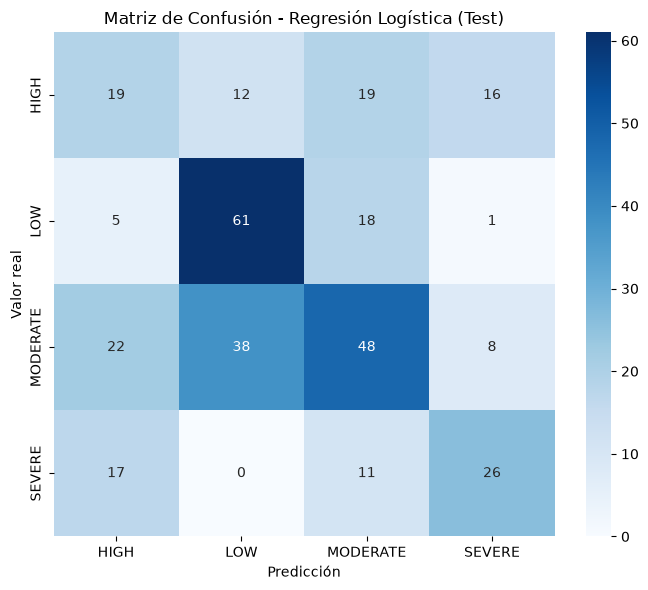

In [17]:
# 1. Tomar el mejor modelo encontrado por el GridSearch
best_model = grid_search.best_estimator_

# 2. Predecir sobre el set de TEST (nunca visto durante el entrenamiento/CV)
y_pred = best_model.predict(X_test_codificado)

# 3. Calcular métricas sobre el test set
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print("==============================================")
print("       MÉTRICAS EN TEST (Regresión Logística)  ")
print("==============================================")
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 4. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión - Regresión Logística (Test)')
plt.tight_layout()
plt.show()

In [24]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# 1. Definir el modelo base
xgb_model = XGBClassifier(
    random_state=46,
    eval_metric='mlogloss'
)

# 2. Definir la parrilla de hiperparámetros
param_grid = {
    'n_estimators': [50,100, 300, 500,1000],
    'max_depth': range(1,10),
    'learning_rate': [0.01, 0.05, 0.1,0.2],
}

# 3. Configurar GridSearch con Validación Cruzada (5 folds)
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("--- Iniciando búsqueda de hiperparámetros (Grid Search) ---")

grid_search.fit(X_train_codificado, y_train)

# 4. Ver los mejores resultados
print("\n==============================================")
print("       MEJORES HIPERPARÁMETROS ENCONTRADOS    ")
print("==============================================")
print(grid_search.best_params_)
print(f"Mejor F1 Weighted en Validación Cruzada: {grid_search.best_score_:.4f}")

--- Iniciando búsqueda de hiperparámetros (Grid Search) ---
Fitting 5 folds for each of 180 candidates, totalling 900 fits

       MEJORES HIPERPARÁMETROS ENCONTRADOS    
{'learning_rate': 0.2, 'max_depth': 1, 'n_estimators': 300}
Mejor F1 Weighted en Validación Cruzada: 0.4755


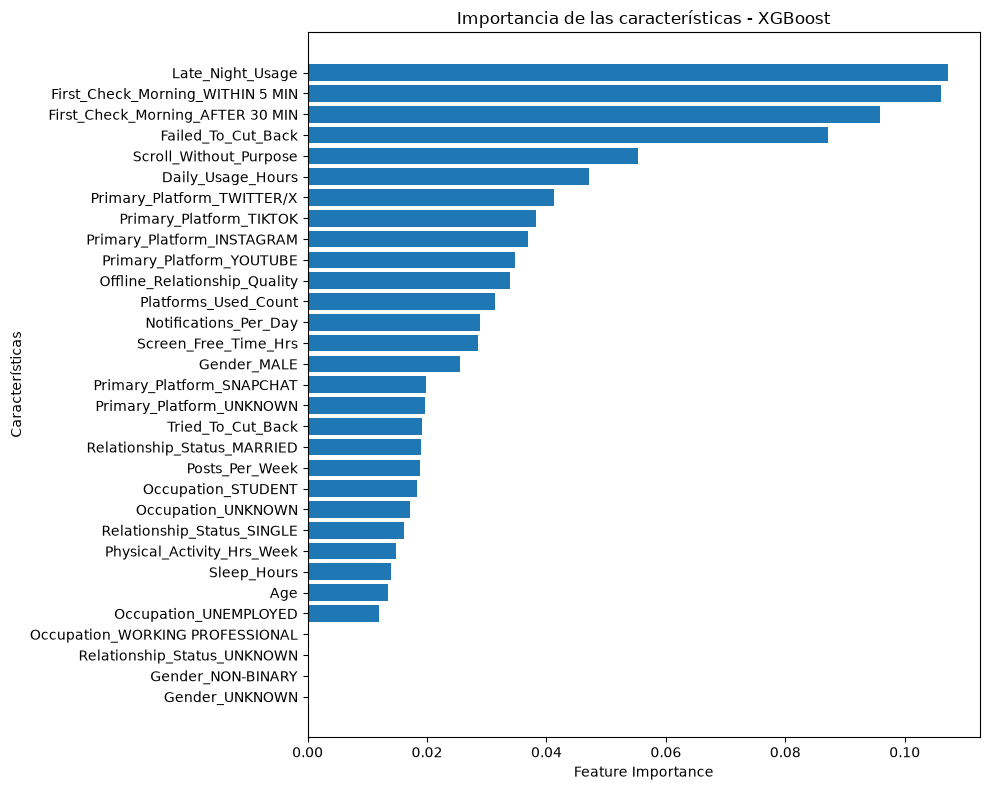

In [ ]:
# Obtener el mejor modelo
mejor_modelo = grid_search.best_estimator_

# Obtener importancia de las características
feature_importance = pd.DataFrame({
    'Feature': X_train_codificado.columns,
    'Importance': mejor_modelo.feature_importances_
})

# Ordenar de menor a mayor para que el gráfico quede bien
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=True
)

# ==========================================
# GRÁFICO DE BARRAS HORIZONTALES
# ==========================================

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Características')
plt.title('Importancia de las características - XGBoost')

plt.tight_layout()
plt.show()

       MÉTRICAS EN TEST (Regresión Logística)  
Accuracy  : 45.48%
Precision : 44.90%
Recall    : 45.48%
F1 Score  : 44.30%

              precision    recall  f1-score   support

        HIGH       0.30      0.30      0.30        66
         LOW       0.52      0.75      0.62        85
    MODERATE       0.46      0.35      0.40       116
      SEVERE       0.50      0.39      0.44        54

    accuracy                           0.45       321
   macro avg       0.44      0.45      0.44       321
weighted avg       0.45      0.45      0.44       321



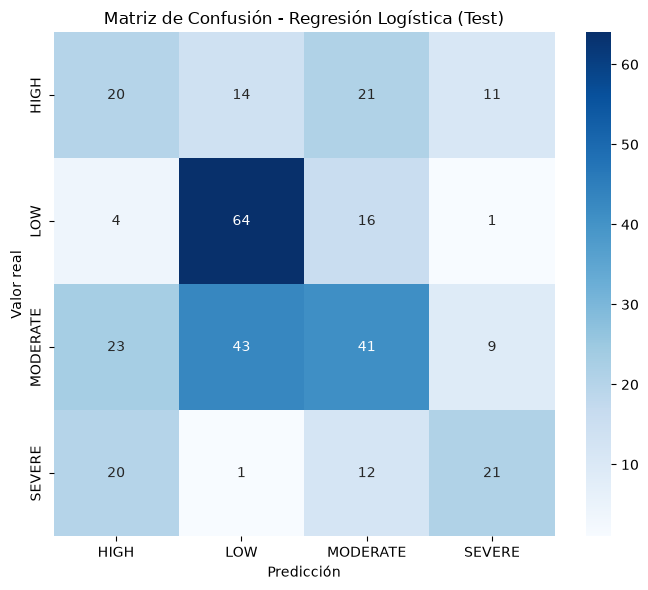

In [27]:
# 1. Tomar el mejor modelo encontrado por el GridSearch
best_model = grid_search.best_estimator_

# 2. Predecir sobre el set de TEST (nunca visto durante el entrenamiento/CV)
y_pred = best_model.predict(X_test_codificado)

# 3. Calcular métricas sobre el test set
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print("==============================================")
print("       MÉTRICAS EN TEST (Regresión Logística)  ")
print("==============================================")
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 4. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión - Regresión Logística (Test)')
plt.tight_layout()
plt.show()